In [ ]:
%pip install pandas
%pip install matplotlib

   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.7 MB 21.4 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.7 MB 21.3 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 19.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ------------- -------------------------- 4.2/12.3 MB 20.5 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.3 MB 20.5 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 20.2 MB/s eta 0:00:00

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]
   ------------- -------------------------- 1/3 [numpy]



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 13.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 19.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 17.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 20.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ----------------------- ---------------- 4.2/7.0 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 17.6 MB/s eta 0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [2]:
df = pd.read_csv(".\\ece447-assignment02\\ece447-assignment02\\data-a2-p1.csv")
df.head()

,student_id,attendance_percent,study_hours_per_week,motivation_level,stress_level,online_activity_hours,assignment_score
0,S01,79,12,6.8,3.1,5.5,81
1,S02,88,16,5.3,5.6,6.4,83
2,S03,74,12,4.7,3.0,4.8,78
3,S04,94,15,8.4,5.5,4.1,87
4,S05,78,15,7.5,8.0,5.0,79


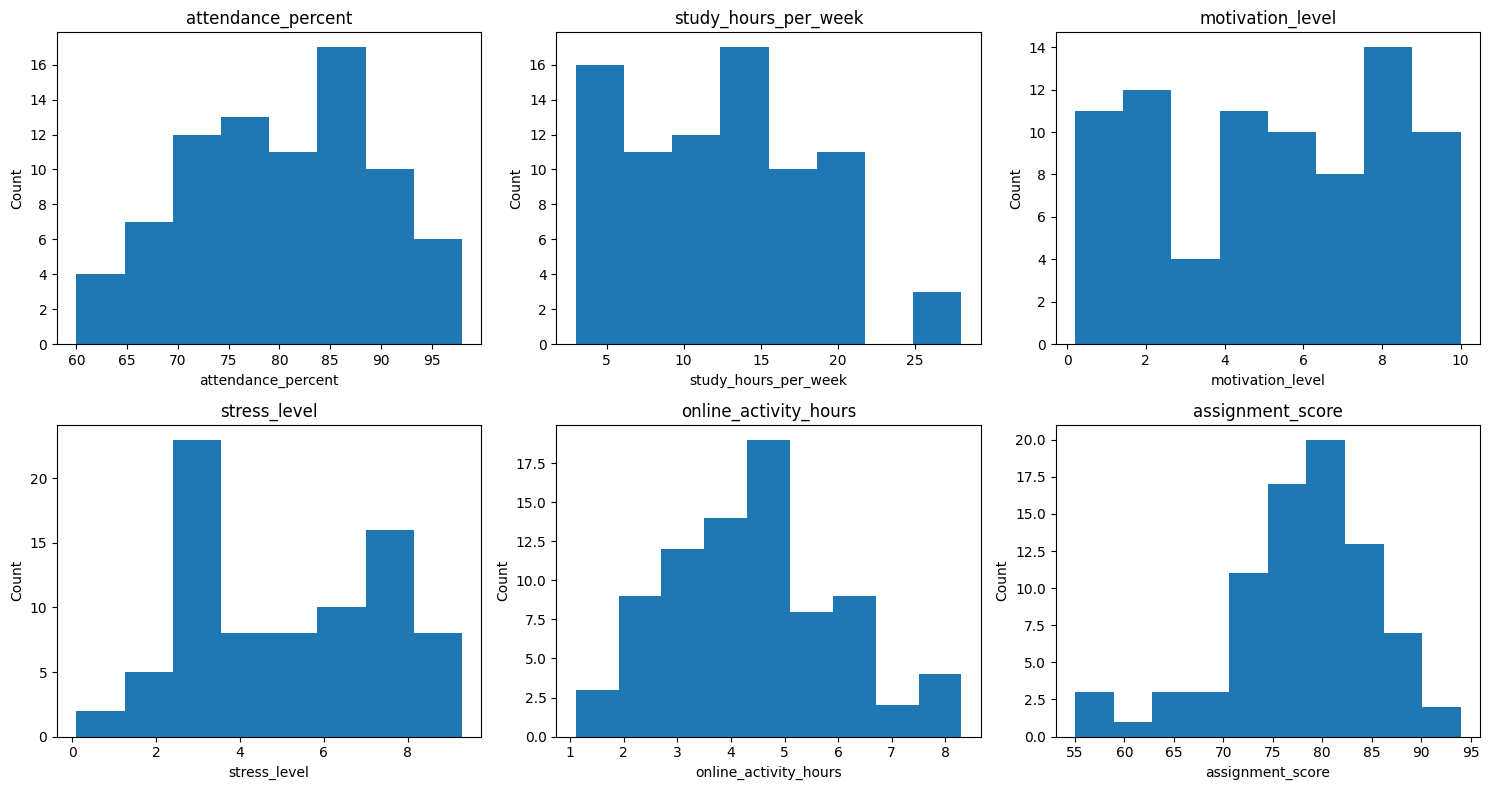

In [3]:
# numeric features only
features = df.select_dtypes(include="number").columns.tolist()

# drop id-like columns (common variants)
for c in ["student_id", "StudentID", "Student Id", "id", "ID"]:
    if c in features:
        features.remove(c)

n = len(features)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(features, start=1):
    x = df[col].dropna()
    ax = plt.subplot(rows, cols, i)
    ax.hist(x, bins="auto")     # you can replace with bins=10 if they want fixed bins
    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()


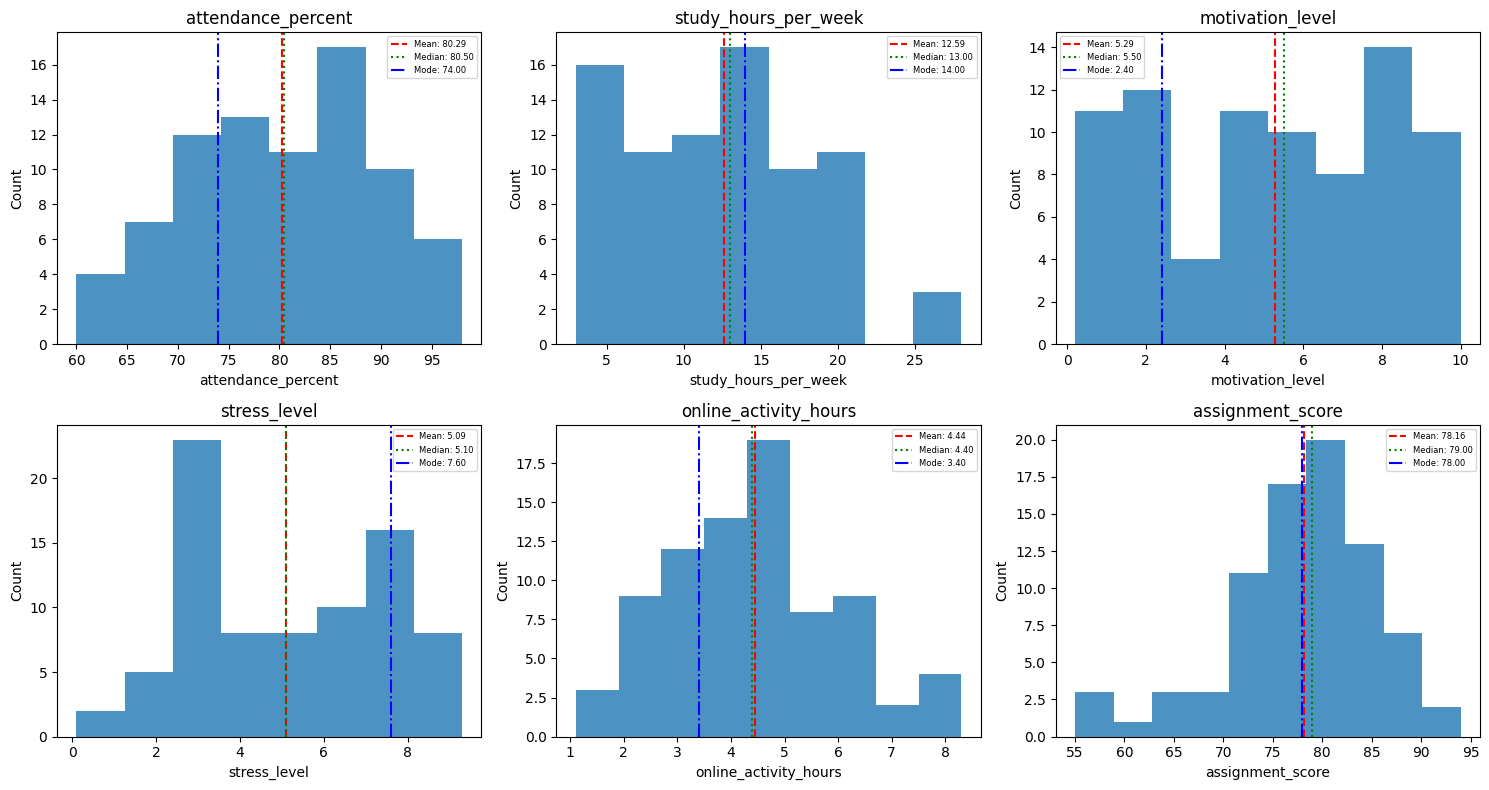

In [7]:
# numeric features only
features = df.select_dtypes(include="number").columns.tolist()

# drop id-like columns (common variants)
for c in ["student_id"]:
    if c in features:
        features.remove(c)

n = len(features)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(features, start=1):
    x = df[col].dropna()
    
    mean_val = x.mean()
    median_val = x.median()
    
    modes = x.mode()
    mode_val = modes.iloc[0] if len(modes) > 0 else float('nan')
    
    ax = plt.subplot(rows, cols, i)
    ax.hist(x, bins="auto", alpha=0.8)
    
    ax.axvline(mean_val, linestyle="--", color="red", label=f"Mean: {mean_val:.2f}")
    ax.axvline(median_val, linestyle=":", color="green", label=f"Median: {median_val:.2f}")
    if not pd.isna(mode_val):
        ax.axvline(mode_val, linestyle="-.", color="blue", label=f"Mode: {mode_val:.2f}")
    
    ax.set_title(f"{col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.legend(fontsize=6)

plt.tight_layout()
plt.show()


attendance_percent: Roughly unimodal and close to normal, centered in the low–mid 80s. The mean and median are very close, suggesting only mild skew.

study_hours_per_week: Right-skewed (longer tail toward higher study hours). Most students cluster around ~10–15 hours, with a few higher-hour values pulling the tail.

motivation_level: Not Gaussian; it looks spread across 0–10 with multiple bumps (so more like multi-modal / irregular, possibly “roughly uniform-ish” but not flat).

stress_level: Looks bimodal (one group around low stress ~2–3 and another around higher stress ~7–8), so definitely not normal.

online_activity_hours: Roughly unimodal and approximately normal around ~4–5 hours, with mild tailing.

assignment_score: Roughly normal/unimodal around ~78–80, but with a left tail (a few low-score outliers around the mid-50s/60s).

In [9]:
import numpy as np

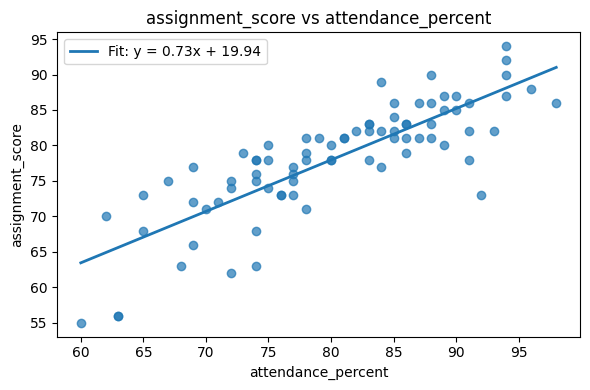

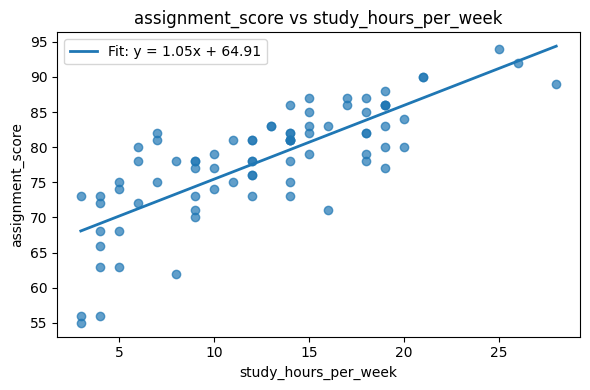

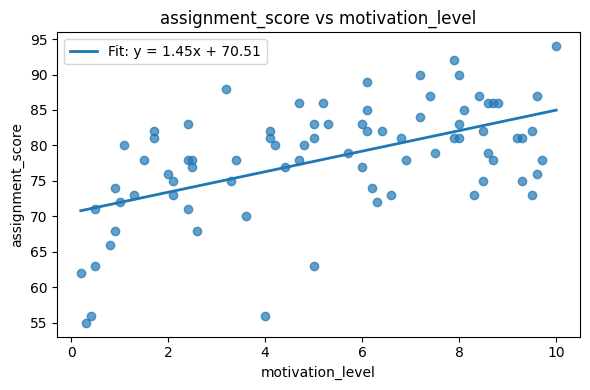

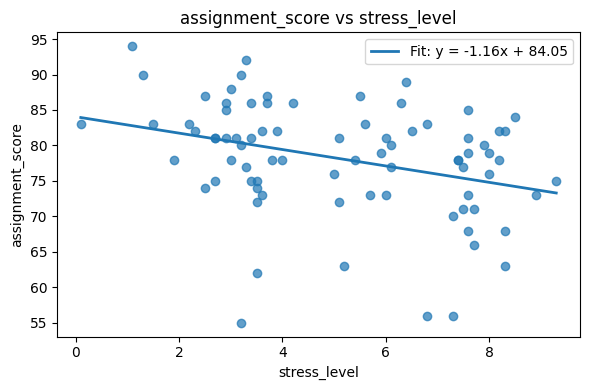

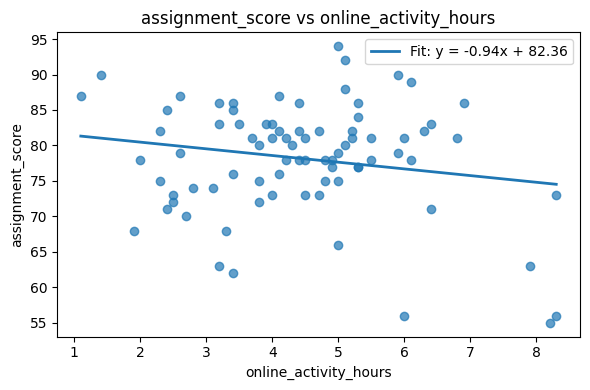

In [11]:
y_col = "assignment_score"

x_features = df.select_dtypes(include="number").columns.tolist()

for c in ["student_id", y_col]:
    if c in x_features:
        x_features.remove(c)
    
for x_col in x_features:
    # drop rows where either x or y is missing
    sub = df[[x_col, y_col]].dropna()
    x = sub[x_col].to_numpy()
    y = sub[y_col].to_numpy()

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.7)

    # best-fit line: y = m*x + b
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b
    plt.plot(x_line, y_line, linewidth=2, label=f"Fit: y = {m:.2f}x + {b:.2f}")

    plt.title(f"{y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [17]:
target = "assignment_score"

# pick numeric columns, drop ID, compute correlations vs assignment_score
numeric_cols = df.select_dtypes(include="number").columns
drop_cols = [c for c in ["student_id"] if c in numeric_cols]

corr = (
    df.drop(columns=drop_cols, errors="ignore")[numeric_cols.drop(drop_cols, errors="ignore")]
      .corr(numeric_only=True)[target]
      .drop(labels=[target], errors="ignore")
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr


attendance_percent       0.824068
study_hours_per_week     0.779994
motivation_level         0.545948
stress_level            -0.334311
online_activity_hours   -0.184641
Name: assignment_score, dtype: float64

attendance_percent (r = 0.824): strong positive relationship — higher attendance is strongly associated with higher assignment scores (tight upward trend).

study_hours_per_week (r = 0.780): strong positive relationship — more study hours generally align with higher scores.

motivation_level (r = 0.546): moderate positive relationship — motivation helps, but there’s noticeably more spread.

stress_level (r = -0.334): weak-to-moderate negative relationship — higher stress tends to correspond to lower scores, but it’s not super tight.

online_activity_hours (r = -0.185): weak negative relationship — a slight tendency for more online activity to relate to lower scores, but it’s a weak signal.